**姓名：** 朱振涛  |  **学号：** BC25219010

### **步骤一：数据预处理**

数据集为混凝土抗压强度数据，包含1030个实例，包含8个输入变量和1个输出变量，需要先
进行以下数据预处理工作。


**相关性分析与特征选择：**
为了挑选数据集的主要特征 ，先计算8个输入特征与输出强度之间的皮尔逊相关系数，并绘制相关性热力图。结果表明，所有8个特征与抗压强度的相关系数绝对值均大于0.1。为了最大程度保留数据方差和有效信息，我决定保留全部8个特征作为主要特征输入。


**数据划分：**
将数据集的前80%划分为训练集，用于模型拟合；后20%作为独立的测试集，用于评估模型的泛化能力。

**特征标准化：**
由于不同输入变量的量纲差异巨大，使用StandardScaler对训练集和测试集的特征进行了标准化处理，确保输入数据具有相同的维度和分布，从而加速梯度下降并防止模型在训练中出现梯度发散。

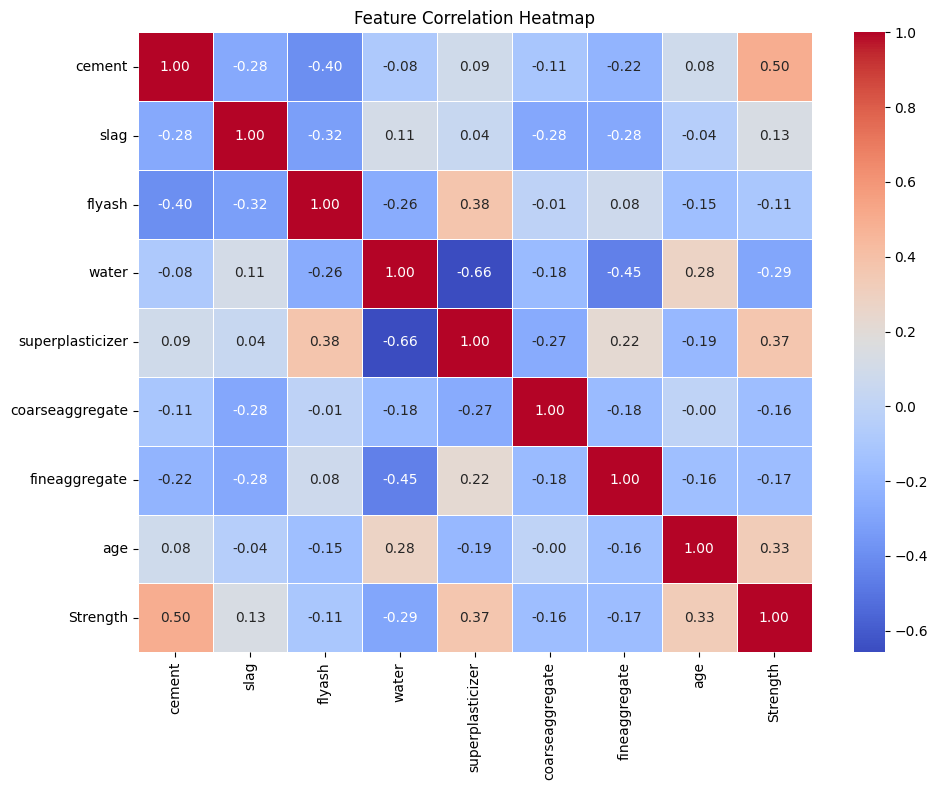

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("/content/Concrete_Data_Yeh.csv")

col_names = list(df.columns)
df.rename(columns={col_names[-1]: 'Strength'}, inplace=True)

# 1.相关性分析与可视化
corr_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# 提取特征
target_corr = corr_matrix['Strength'].drop('Strength')
selected_features = target_corr[abs(target_corr) > 0.1].index.tolist()
X = df[selected_features].values
y = df['Strength'].values

# 2.数据划分与标准化
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

### **步骤二：多层感知机模型构建与训练**

本实验基于PyTorch深度学习框架搭建了前馈神经网络模型，并针对不同激活函数做了对比实验。

**网络拓扑结构**：
模型采用`8 -> 64 -> 32 -> 1` 的全连接层架构。输入层接收8维特征向量；中间设置两个隐藏层（分别包含64和32个神经元）以充分提取高阶特征；输出层设定为单一神经以直接输出预测的抗压强度。模型统一使用 Adam 优化器（lr=0.01）和均方误差（MSE）作为损失函数。

**对比实验**：
为了探究不同非线性激活函数对网络收敛性能的影响，本实验在控制其他超参数不变的前提下，分别使用ReLU、Tanh和LeakyReLU（负半轴斜率设为0.01）作为隐藏层激活函数，构建了三个结构相同的独立模型，并在训练集上完整迭代了600个 Epoch，进行平行对比。

**训练收敛性与Loss轨迹分析**：
通过绘制并观察训练过程的Loss下降曲线（MSE），可以发现LeakyReLU 模型（绿线）的训练误差下降极其迅速，并最终达到了最低的训练损失；Tanh 模型（红线）初期收敛稍缓，但整体下降趋势十分稳定；ReLU 模型（蓝线）下降平稳但最终的训练误差相对偏高。

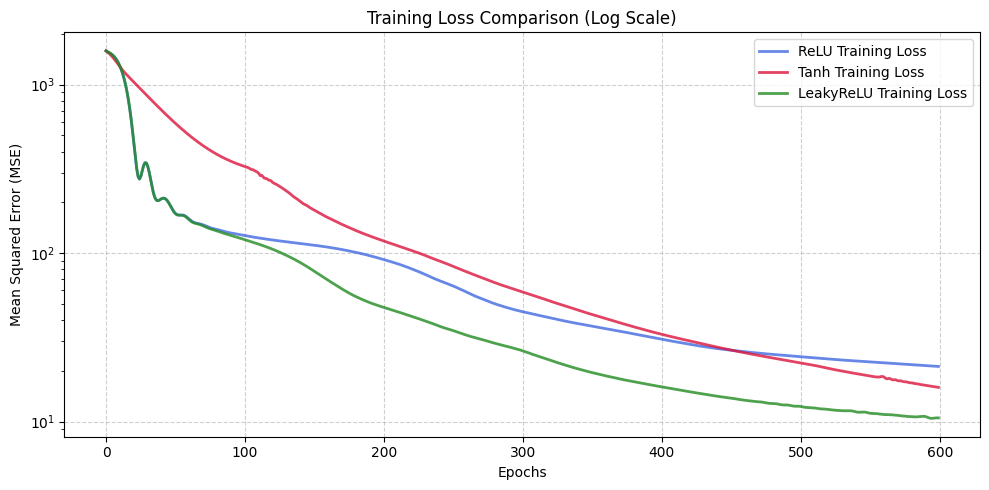

In [ ]:
# 1.定义多层感知机回归模型
class ConcreteNN(nn.Module):
    def __init__(self, input_dim, activation_fn):
        super(ConcreteNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.act1 = activation_fn
        self.fc2 = nn.Linear(64, 32)
        self.act2 = activation_fn
        self.output_layer = nn.Linear(32, 1)

    def forward(self, x):
        x = self.act1(self.fc1(x))
        x = self.act2(self.fc2(x))
        return self.output_layer(x)

# 2.定义训练函数
def train_model(model_name, activation_fn, input_dim, epochs=600, lr=0.01):
    model = ConcreteNN(input_dim=input_dim, activation_fn=activation_fn)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_history = []

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        predictions = model(X_train_tensor)
        loss = criterion(predictions, y_train_tensor)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return model, loss_history

# 3.执行对比训练并记录数据
activations_to_test = {
    "ReLU": nn.ReLU(),
    "Tanh": nn.Tanh(),
    "LeakyReLU": nn.LeakyReLU(negative_slope=0.01)
}

trained_models = {}
results_loss = {}
input_dimension = len(selected_features)

for name, act_fn in activations_to_test.items():
    torch.manual_seed(42)
    model, losses = train_model(name, act_fn, input_dim=input_dimension, epochs=600, lr=0.01)
    trained_models[name] = model
    results_loss[name] = losses

# 4.绘制训练Loss下降对比曲线
colors = ['royalblue', 'crimson', 'forestgreen']
plt.figure(figsize=(10, 5))
for (name, losses), color in zip(results_loss.items(), colors):
    plt.plot(losses, label=f'{name} Training Loss', color=color, alpha=0.8, linewidth=2)
plt.title('Training Loss Comparison (Log Scale)')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error (MSE)')
plt.yscale('log')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### **步骤三：测试集评估与预测性能可视化**

模型训练完成后，使用预留的独立测试集对三个模型进行最终的定量评估与可视化分析，揭示模型在未知数据上的真实泛化能力。

**测试集定量评估（MSE）：**
分别计算三个模型在测试集上的MSE，结果显示，Tanh模型在测试集上取得了最优的预测精度（MSE=26.10），优于LeakyReLU（32.08）和ReLU（34.37）。对比步骤二中的训练情况可以发现，尽管LeakyReLU在训练集上误差最低，但在测试集上出现了一定程度的“过拟合”；而Tanh模型则表现出了最稳健的泛化能力。

**真实值vs预测值可视化：**
观察Target与Output的散点对比图可知，Tanh模型的预测点最为紧凑地聚集在理想预测基准线（$y=x$）的两侧，没有明显的发散。相对而言，LeakyReLU和ReLU模型在个别样本上出现了较大的预测偏差。

**最终结论：**
综合表明，在本次回归预测任务中，采用Tanh作为隐藏层激活函数的多层感知机模型表现最为优异，它成功提取了特征间的底层非线性规律，并在测试集上展现出了较高的预测精度。

=== 测试集最终评估结果 ===
[ReLU] 最终测试集 MSE: 34.37
[Tanh] 最终测试集 MSE: 26.10
[LeakyReLU] 最终测试集 MSE: 32.08


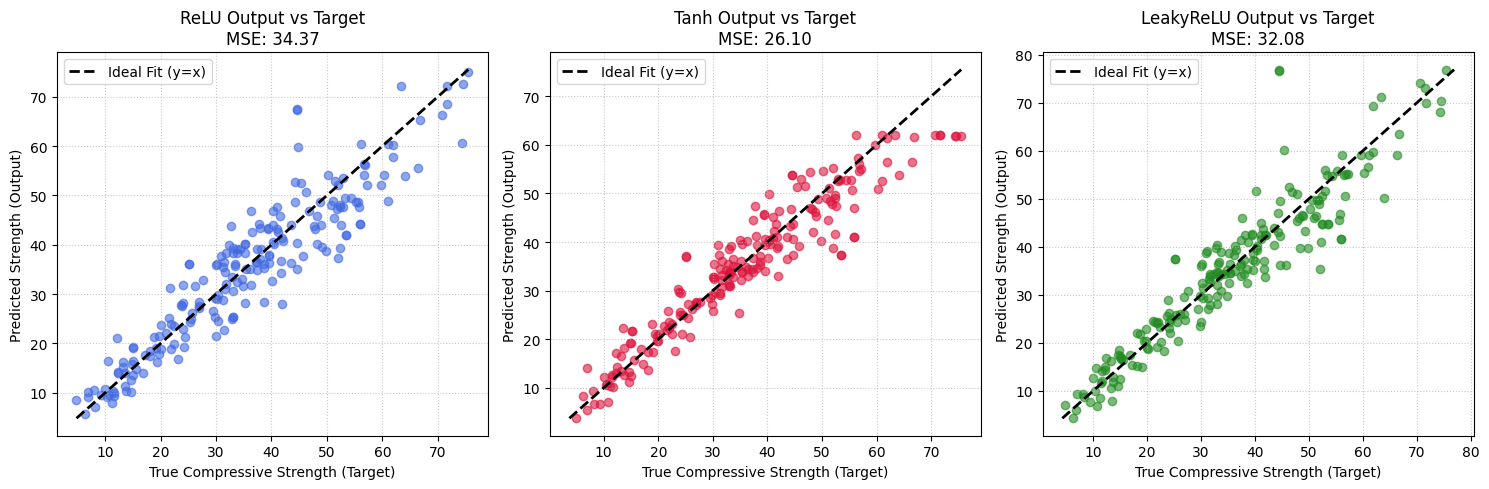

In [ ]:
criterion = nn.MSELoss()
results_mse = {}
results_preds = {}

# 1.在独立的测试集上评估模型
print("=== 测试集最终评估结果 ===")
for name, model in trained_models.items():
    model.eval()
    with torch.no_grad():
        test_predictions = model(X_test_tensor)
        test_mse = criterion(test_predictions, y_test_tensor).item()
        results_mse[name] = test_mse
        results_preds[name] = test_predictions.numpy()
    print(f"[{name}] 最终测试集 MSE: {test_mse:.2f}")

# 2.绘制Target与Output对比散点图
y_test_numpy = y_test_tensor.numpy()
colors = ['royalblue', 'crimson', 'forestgreen']

plt.figure(figsize=(15, 5))
for i, (name, preds) in enumerate(results_preds.items()):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test_numpy, preds, alpha=0.6, color=colors[i])

    # 绘制完美的y=x预测基准线
    min_val = min(y_test_numpy.min(), preds.min())
    max_val = max(y_test_numpy.max(), preds.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Ideal Fit (y=x)')

    plt.title(f'{name} Output vs Target\nMSE: {results_mse[name]:.2f}')
    plt.xlabel('True Compressive Strength (Target)')
    plt.ylabel('Predicted Strength (Output)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()